##NAME:JAWAD HASSAN
##ROLL:2230-0035
##BSAI

In [78]:
#library
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN

In [28]:
#dataset load
df=pd.read_csv("/content/diabetes.csv")
#binary classification dataset

In [64]:
#PART A preprocess
print(df.size)
print(df.shape)#shape
print(df.describe())
print(df.info())#attributes
print(df.head())
print(df.tail())

3840
(768, 5)
          Insulin     Glucose  BloodPressure         Age         BMI
count  768.000000  768.000000     768.000000  768.000000  768.000000
mean   141.997396  121.677083      72.399740   33.240885   32.432682
std     89.061425   30.464161      12.108068   11.760232    6.880709
min     14.000000   44.000000      24.000000   21.000000   18.200000
25%    103.000000   99.750000      64.000000   24.000000   27.500000
50%    103.000000  117.000000      72.000000   29.000000   32.050000
75%    170.000000  140.250000      80.000000   41.000000   36.600000
max    846.000000  199.000000     122.000000   81.000000   67.100000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Insulin        768 non-null    float64
 1   Glucose        768 non-null    float64
 2   BloodPressure  768 non-null    float64
 3   Age            768 non-null    int64

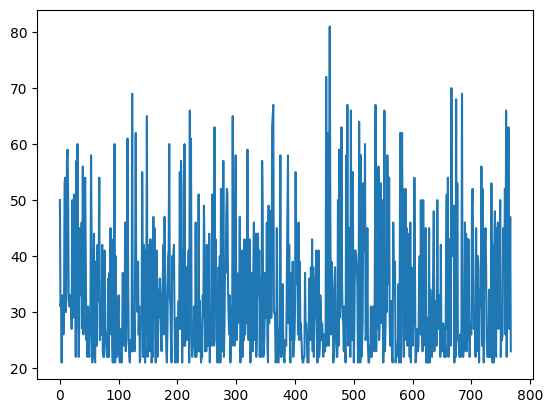

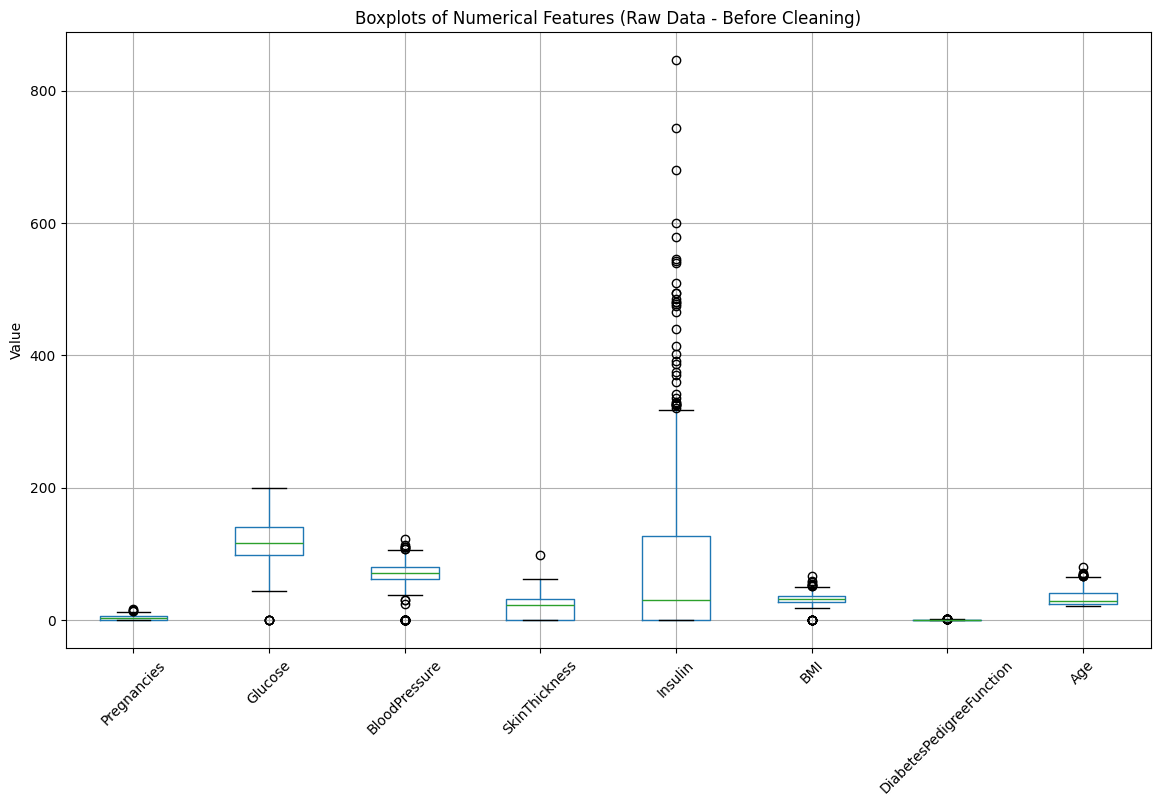

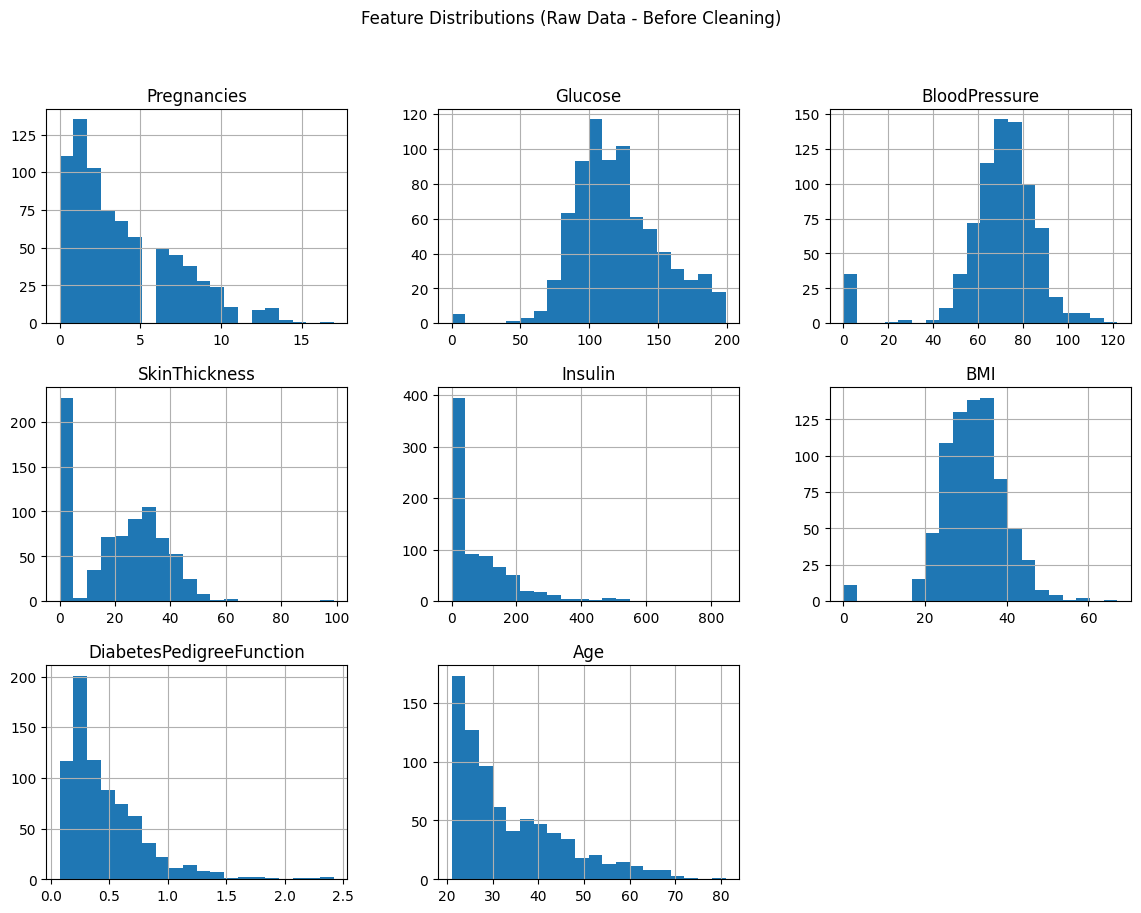

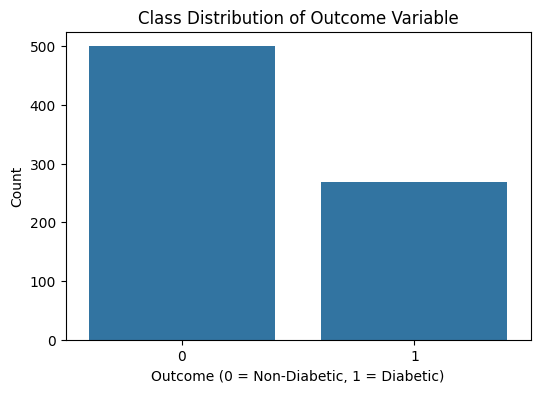

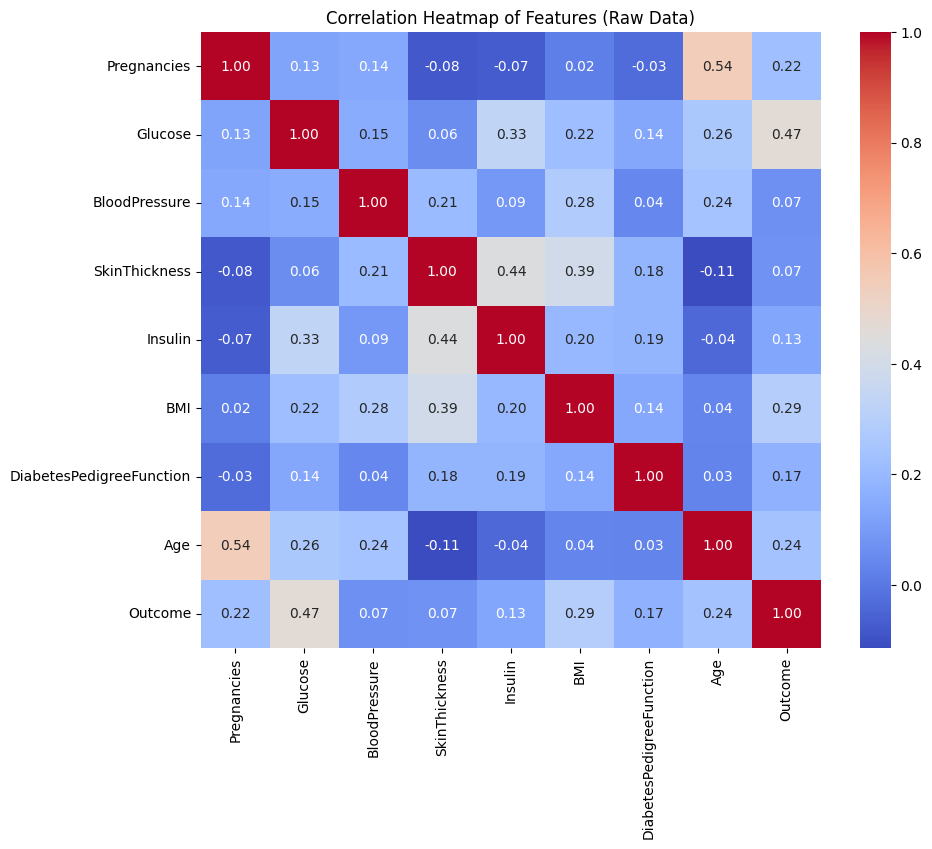

In [30]:
#eda visualize class distribution
plt.plot(df['Age'])
# Boxplots of Numerical Features (Before Cleaning)
plt.figure(figsize=(14, 8))
df.drop(columns=["Outcome"]).boxplot()
plt.title("Boxplots of Numerical Features (Raw Data - Before Cleaning)")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.show()
#  Histograms of Numerical Features (Before Cleaning)
df.drop(columns=["Outcome"]).hist(figsize=(14, 10), bins=20)
plt.suptitle("Feature Distributions (Raw Data - Before Cleaning)")
plt.show()
# Outcome Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Outcome", data=df)
plt.title("Class Distribution of Outcome Variable")
plt.xlabel("Outcome (0 = Non-Diabetic, 1 = Diabetic)")
plt.ylabel("Count")
plt.show()
#  Correlation Heatmap (Raw Data)
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Features (Raw Data)")
plt.show()

In [35]:
#Missing Value 0 Analysis & Target-Aware Imputation
print('bp mean:',df['BloodPressure'].mean())
print('bp std:',df['BloodPressure'].std())
df.isnull().sum()
df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']]=df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']].replace(0, np.nan)
df.isnull().sum()
def median_target(var):
    temp = df[df[var].notnull()]
    temp=temp[[var,'Outcome']].groupby(['Outcome'])[[var]].median().reset_index()
    return temp
print(median_target('Glucose'))
print(median_target('BloodPressure'))
print(median_target('SkinThickness'))
print(median_target('Insulin'))
print(median_target('BMI'))
df.loc[(df['Outcome'] == 0 ) & (df['Glucose'].isnull()),'Glucose'] = 107
df.loc[(df['Outcome'] == 1 ) & (df['Glucose'].isnull()),'Glucose'] = 140
#Same for Blood Pressure, Skin Thickness, Insulin andBMI:

df.loc[(df['Outcome'] == 0 ) & (df['BloodPressure'].isnull()),'BloodPressure'] = 70
df.loc[(df['Outcome'] == 1 ) & (df['BloodPressure'].isnull()),'BloodPressure'] = 75

df.loc[(df['Outcome'] == 0 ) & (df['SkinThickness'].isnull()),'SkinThickness'] = 27
df.loc[(df['Outcome'] == 1 ) & (df['SkinThickness'].isnull()),'SkinThickness'] = 32

df.loc[(df['Outcome'] == 0 ) & (df['Insulin'].isnull()),'Insulin'] = 103
df.loc[(df['Outcome'] == 1 ) & (df['Insulin'].isnull()),'Insulin'] = 170

df.loc[(df['Outcome'] == 0 ) & (df['BMI'].isnull()),'BMI'] = 30
df.loc[(df['Outcome'] == 1 ) & (df['BMI'].isnull()),'BMI'] = 34

print(df.isnull().sum())
# Zero Value Count in Each Column using (df == 0).sum()
print("Count of Zero Values in Each Column ((df == 0).sum()):")
print((df == 0).sum())


bp mean: 72.39973958333333
bp std: 12.108068357852577
   Outcome  Glucose
0        0    107.0
1        1    140.0
   Outcome  BloodPressure
0        0           70.0
1        1           75.0
   Outcome  SkinThickness
0        0           27.0
1        1           32.0
   Outcome  Insulin
0        0    103.0
1        1    170.0
   Outcome    BMI
0        0  30.05
1        1  34.25
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Count of Zero Values in Each Column ((df == 0).sum()):
Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome               

     Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
PC1     0.002502  0.180775       0.011428       0.020747  0.982887  0.018864   
PC2     0.019879  0.961859       0.133439       0.058764 -0.183007  0.040146   
PC3     0.105947 -0.202432       0.733597       0.189802  0.010813  0.135091   
PC4     0.112057 -0.002157      -0.430380      -0.395707  0.007165 -0.362420   
PC5     0.047022 -0.033535      -0.496614       0.748417 -0.015550  0.335763   
PC6     0.007807 -0.004916      -0.109447      -0.493262 -0.005642  0.857700   
PC7     0.986659  0.003787      -0.008091      -0.008438  0.000008  0.003053   
PC8     0.006950 -0.000821       0.001863      -0.000465 -0.000290 -0.006222   

     DiabetesPedigreeFunction       Age  
PC1                  0.000552  0.018174  
PC2                  0.000851  0.134420  
PC3                 -0.000346  0.596021  
PC4                 -0.001224  0.717096  
PC5                  0.003465  0.277345  
PC6                  0.0054

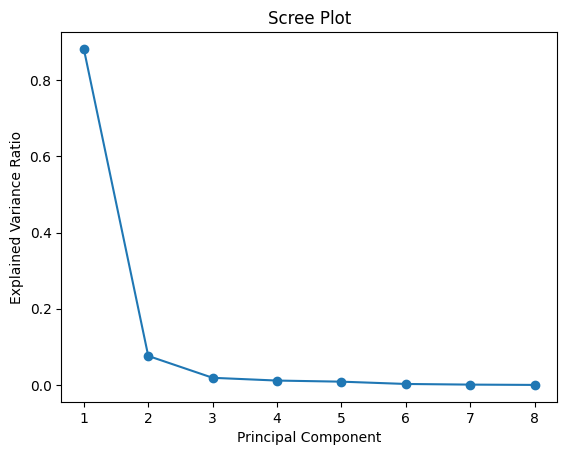

In [37]:
#pca
y = df['Outcome']   # target column
df_without_outcome = df.drop("Outcome", axis = 1)
from sklearn.decomposition import PCA
pca = PCA()
pca.fit_transform(df_without_outcome)
pca.get_covariance()
explained_variance = pca.explained_variance_ratio_
explained_variance
loadings = pd.DataFrame(
    pca.components_,  # each row = PC, each column = original feature weights
    columns=df_without_outcome.columns,
    index=[f'PC{i+1}' for i in range(len(df_without_outcome.columns))]
)

# Show contributions for all PCs
print(loadings)

# Optional: just see PC1 contributions
print("\nFeature contributions to PC1:")
print(loadings.loc['PC1'].sort_values(ascending=False))
plt.plot(range(1, 9), pca.explained_variance_ratio_, marker='o')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.show()


In [43]:
#feature drop after pca
df = df[['Insulin','Glucose','BloodPressure','Age','BMI',]]
df.head()

,Insulin,Glucose,BloodPressure,Age,BMI
0,170.0,148.0,72.0,50,33.6
1,103.0,85.0,66.0,31,26.6
2,170.0,183.0,64.0,32,23.3
3,94.0,89.0,66.0,21,28.1
4,168.0,137.0,40.0,33,43.1


#justification:
##the reason we performed pre processing is beacause our data consisted of alot of 0 values in insulin, bmi,age,bp and skin thickness which is not logically and humanly possible so we calculated each feature madian and replaced all 0 with median plus we also performed pca and checked which feature is most top important, so we kept those and dropped irrelevant features which is called feature dimensionality reductions based on pca

In [46]:
#Separate target and features
X = df # features
y   # target column
X

,Insulin,Glucose,BloodPressure,Age,BMI
0,170.0,148.0,72.0,50,33.6
1,103.0,85.0,66.0,31,26.6
2,170.0,183.0,64.0,32,23.3
3,94.0,89.0,66.0,21,28.1
4,168.0,137.0,40.0,33,43.1
...,...,...,...,...,...
763,180.0,101.0,76.0,63,32.9
764,103.0,122.0,70.0,27,36.8
765,112.0,121.0,72.0,30,26.2
766,170.0,126.0,60.0,47,30.1


In [48]:
#feature scaling
scaler = StandardScaler() #0-1
X_scaled = scaler.fit_transform(X)


In [65]:
#Train-test split
xtrain, xtest, ytrain, ytest = train_test_split(X_scaled, y, test_size=0.15, random_state=0)

In [53]:
#PART B supervised learning 2 models knn and svm model
models = {  #dictionary
    'KNN': KNeighborsClassifier(n_neighbors=5),  # 5 odd value for majority voting
    'SVM': SVC(kernel='rbf', random_state=0)    # default RBF kernel
       }

In [62]:
# trainning trainning
for name,model in models.items():
    model.fit(xtrain, ytrain)
    ypred = model.predict(xtest)
 #model evaluation metics: accuracy,precision,recall and f1score
    print(f"\n--- {name} ---")
    print('Accuracy:', accuracy_score(ytest, ypred))
    print('Confusion Matrix:\n', confusion_matrix(ytest, ypred))
    print('Classification Report:\n', classification_report(ytest, ypred))


--- KNN ---
Accuracy: 0.853448275862069
Confusion Matrix:
 [[69  9]
 [ 8 30]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.88      0.89        78
           1       0.77      0.79      0.78        38

    accuracy                           0.85       116
   macro avg       0.83      0.84      0.83       116
weighted avg       0.85      0.85      0.85       116


--- SVM ---
Accuracy: 0.8362068965517241
Confusion Matrix:
 [[68 10]
 [ 9 29]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.87      0.88        78
           1       0.74      0.76      0.75        38

    accuracy                           0.84       116
   macro avg       0.81      0.82      0.82       116
weighted avg       0.84      0.84      0.84       116



#comparison:
###The results  indicate that the KNN model performs best overall for this diabetes classification dataset. KNN achieves the highest accuracy of 85% and a strong precision of 90% while svm 83%, knn showing its effectiveness in correctly identifying diabetic cases. KNN  maintains a competitive F1-score of 89%  indicating fewer prediction errors. Overall, the combination of high accuracy and strong precision makes KNN the most reliable model for this dataset. Also the marco and weighted average of KNN is better than of SVM

In [69]:
#PART C: ENSEMBLE LEARNING
#RANDOM FOREST CLASSIFIER
rf = RandomForestClassifier(n_estimators=100, random_state=42)

#  Train the model
rf.fit(xtrain, ytrain)

# Make predictions
y_pred = rf.predict(xtest)

# Calculate evaluation metrics
accuracy = accuracy_score(ytest, y_pred)
precision = precision_score(ytest, y_pred, average='macro')
recall = recall_score(ytest, y_pred, average='macro')
f1 = f1_score(ytest, y_pred, average='macro')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Accuracy : 0.896551724137931
Precision: 0.8825910931174089
Recall   : 0.8825910931174089
F1-score : 0.8825910931174089


#comparison with part B
##Random foret accuracy 90% came out better than part b both knn 85% and svm 83%accuracy making it the better model yet.

In [77]:
#PART D UNSUPERVISED LEARNING
#K MEANS CLUSTERING

# Apply K-Means
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

#evaluation:

# Metric A: Sum of Squared Errors (SSE) / Inertia
sse = kmeans.inertia_
print(f"Sum of Squared Errors (SSE): {sse:.2f}")

#  Metric B: Silhouette Score
# Measures how similar a point is to its own cluster compared to other clusters
# Ranges from -1 (bad) to +1 (perfect)
#came out low 0.2 that means clusters are clouded and not islands
sil_score = silhouette_score(X_scaled, kmeans_labels)
print(f"Silhouette Score: {sil_score:.4f}")

Sum of Squared Errors (SSE): 1722.98
Silhouette Score: 0.2006


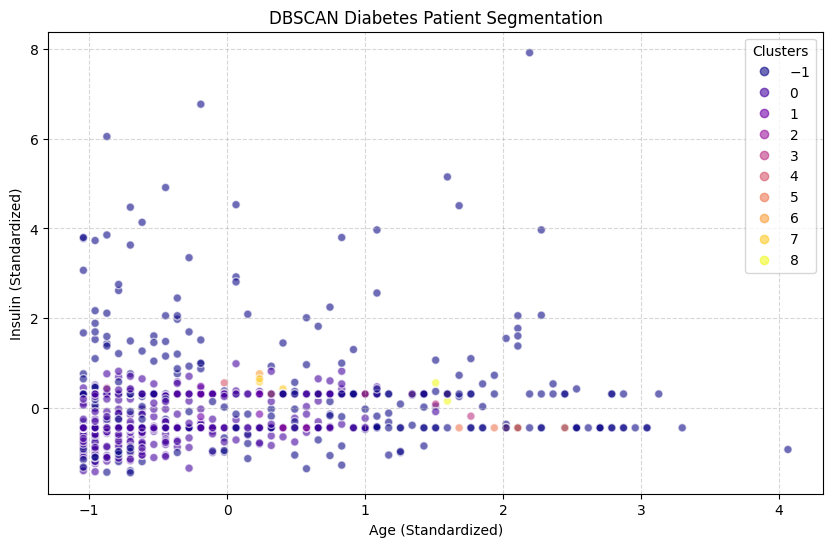

In [84]:
#dbscan
dbscan = DBSCAN(eps=0.7, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)
# Visualization
feature_x_idx = 3 # Age
feature_y_idx = 0 # Insulin

plt.figure(figsize=(10, 6))

#  Plotting
scatter = plt.scatter(X_scaled[:, feature_x_idx],
                      X_scaled[:, feature_y_idx],
                      c=df['DBSCAN_Cluster'],
                      cmap='plasma',
                      alpha=0.6,
                      edgecolors='w')

plt.legend(*scatter.legend_elements(), title="Clusters")
plt.xlabel("Age (Standardized)")
plt.ylabel("Insulin (Standardized)")
plt.title("DBSCAN Diabetes Patient Segmentation")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#identifying noise points
##In DBSCAN, -1 represents outliers noise.
showing half patients dont fit any patterns that is the significance of outliers noise points.

#BONUS
##EXPLAINATION:ONE REAL WORLD EXAMPLE LIKE: In credit card fraud, you are fighting a living enemy. While a supervised model is great for catching known scams like a typical gas station test for a stolen card, it is completely blind to new tactics. Here is why Unsupervised methods Clustering and Anomaly Detection are the better performance in modern credit card security. classification groups according to label data where as clustering makes groups itself based on distance or patterns.